<a href="https://colab.research.google.com/github/Letch49/ML-vvsu-2025-2026/blob/master/%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D0%B5%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_5_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание 5.2

По итоговому датасету:

1. Преобразовать текстовые данные (очистка + токенизация + нормализация).
2. Обучить модель **Word2Vec** на текстах.
3. Заполнить пропуски в числовых признаках через **SimpleImputer**.
4. Выбрать алгоритм **кластеризации** и построить кластеры.
5. Построить модель для **предсказания кластера** (supervised) с подбором гиперпараметров через **GridSearchCV**.


In [18]:
!pip install pymorphy3 gensim scikit-learn nltk


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Qweeck\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [2]:
# Базовые импорты
import pandas as pd
import numpy as np


In [3]:
import sqlite3
conn = sqlite3.connect("parsers/news.db")
df = pd.read_sql_query("SELECT * FROM articles;", conn)
conn.close()



In [4]:
df.head()

,guid,title,description,url,published_at,comments_count,created_at_utc,rating
0,222da855-5a95-47c3-bd72-a8d072167230,Подпорная стена обрушилась на припаркованные а...,"Утро 30 марта принесло автовладельцам, припарк...",https://www.newsvl.ru/accidents/2016/03/30/145...,2016-03-30 12:36:00,0,2025-12-19 04:30:54,0
1,3fdd0a12-1c07-410a-a288-75a5cf1f9bb5,Жители Владивостока обнаружили у Токаревского ...,"В четверг, 26 мая, у берега на Токаревской кош...",https://www.newsvl.ru/accidents/2016/05/26/147...,2016-05-26 19:35:00,0,2025-12-19 04:30:54,0
2,35f5c0eb-7fcb-4528-a082-588769c96637,На Адмирала Кузнецова упавшая подпорная стена ...,Ещё одна подпорная стена рухнула 17 июня ночью...,https://www.newsvl.ru/accidents/2016/06/17/148...,2016-06-17 15:50:00,0,2025-12-19 04:30:55,0
3,3365b29c-f44f-44ee-a53b-b71ed6d01666,В Приморье фиксируются нарушения в ходе предвы...,Сотрудники правоохранительных органов регулярн...,https://www.newsvl.ru/accidents/2016/09/16/151...,2016-09-16 20:57:00,0,2025-12-19 04:31:09,0
4,0b44be6e-6818-4445-a5fd-514ae04088b8,Следователи разыскивают очевидцев падения воро...,Следователи Фрунзенского района Владивостока р...,https://www.newsvl.ru/accidents/2017/01/20/155...,2017-01-20 11:09:00,0,2025-12-19 04:31:23,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14064 entries, 0 to 14063
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   guid            14064 non-null  object
 1   title           14064 non-null  object
 2   description     14064 non-null  object
 3   url             14064 non-null  object
 4   published_at    14064 non-null  object
 5   comments_count  14064 non-null  int64 
 6   created_at_utc  14064 non-null  object
 7   rating          14064 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 879.1+ KB


## Предобработка

In [6]:
import re
import nltk
from nltk.corpus import stopwords

In [8]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Qweeck\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
from pymorphy3 import MorphAnalyzer

In [10]:
STOP_RU = set(stopwords.words("russian"))
TOKEN_RE = re.compile(r"[А-Яа-яA-Za-z]+", flags=re.U)
morph = MorphAnalyzer()

def preprocess_text(text: str):
    if not isinstance(text, str):
        text = "" if text is None else str(text)

    text = text.lower()
    tokens = TOKEN_RE.findall(text)
    
    lemmas = []
    for token in tokens:
        # Отсекаем короткий мусор 💀
        if len(token) <= 2:
            continue
    
        # Русские и латинские слова отдельно (иноагенты)
        if re.match(r"[а-я]", token):
            # Русское слово: нормальная форма через pymorphy3
            if token in STOP_RU:
                continue
            parsed = morph.parse(token)[0]
            lemma = parsed.normal_form
            if lemma in STOP_RU:
                continue
        else:
            # Латинское/английское слово — оставляем как есть
            lemma = token
    
        lemmas.append(lemma)

    return lemmas
text_col = "description"  # ваша текстовая колонка
tokenized_texts = df[text_col].astype(str).apply(preprocess_text).tolist()


In [11]:
sample_text = df["description"].iloc[0]
print(sample_text[:100], "...")

preprocess_text(sample_text)[:100]

Утро 30 марта принесло автовладельцам, припарковавшим машины у домов на
Адмирала Кузнецова, 68
и
66
 ...


['утро',
 'март',
 'принести',
 'автовладелец',
 'припарковать',
 'машина',
 'дом',
 'адмирал',
 'кузнецов',
 'неприятный',
 'известие',
 'трехуровневый',
 'бетонный',
 'подпорный',
 'стена',
 'обрушиться',
 'автомобиль',
 'причинить',
 'серьёзный',
 'повреждение',
 'пострадать',
 'toyota',
 'prius',
 'honda',
 'fit',
 'предположительно',
 'toyota',
 'probox',
 'автомобиль',
 'toyota',
 'prius',
 'повредить',
 'дверь',
 'левый',
 'сторона',
 'оторвать',
 'зеркало',
 'осколок',
 'разбитый',
 'стекло',
 'полететь',
 'салон',
 'практически',
 'идентичный',
 'повреждение',
 'оранжевый',
 'honda',
 'fit',
 'зеркало',
 'дверь',
 'также',
 'прийтись',
 'ремонтировать',
 'хозяин',
 'пострадать',
 'probox',
 'рабочий',
 'огородить',
 'территория',
 'дтп',
 'сообщить',
 'корреспондент',
 'местный',
 'житель',
 'мнение',
 'подпорный',
 'стена',
 'рухнуть',
 'причина',
 'изношенность',
 'весь',
 'протяжённость',
 'бетонный',
 'плита',
 'давно',
 'крениться',
 'сторона',
 'придомовый',
 'дорога',
 

In [12]:
# Уже делали выше, но для проверки нашего массива стоило выполнить
tokenized_texts[0][:40]

['утро',
 'март',
 'принести',
 'автовладелец',
 'припарковать',
 'машина',
 'дом',
 'адмирал',
 'кузнецов',
 'неприятный',
 'известие',
 'трехуровневый',
 'бетонный',
 'подпорный',
 'стена',
 'обрушиться',
 'автомобиль',
 'причинить',
 'серьёзный',
 'повреждение',
 'пострадать',
 'toyota',
 'prius',
 'honda',
 'fit',
 'предположительно',
 'toyota',
 'probox',
 'автомобиль',
 'toyota',
 'prius',
 'повредить',
 'дверь',
 'левый',
 'сторона',
 'оторвать',
 'зеркало',
 'осколок',
 'разбитый',
 'стекло']

## Обучение модели

In [13]:
from gensim.models import Word2Vec
import numpy as np

w2v = Word2Vec(
    sentences=tokenized_texts,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,
    epochs=10,
)


In [14]:
def doc_vector(tokens, model):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

doc_vectors = np.vstack([doc_vector(t, w2v) for t in tokenized_texts])
doc_vectors.shape

(14064, 100)

In [15]:
doc_vectors[:3]

array([[-0.01446275,  0.0456825 ,  0.04446506,  0.2666872 , -0.02796514,
        -0.19726329, -0.3143431 ,  0.40677178, -0.0172717 ,  0.23637314,
        -0.27009276,  0.04115027, -0.04869941, -0.16138269, -0.17451926,
         0.11105857, -0.05994134, -0.22370106, -0.0009545 , -0.40896577,
         0.15367615,  0.0410898 ,  0.04405787, -0.22993232, -0.25277644,
        -0.04972209,  0.15664312, -0.03539037,  0.05691763, -0.08529615,
        -0.04403359,  0.35282227,  0.06183477,  0.05059024, -0.12715605,
         0.15146966,  0.11185579, -0.31238398,  0.04698564, -0.12877838,
         0.05766113, -0.5497276 ,  0.0294063 , -0.40884587,  0.09914726,
        -0.22291458, -0.48526084,  0.21151166,  0.09433757, -0.11834942,
        -0.0430205 , -0.09047838,  0.00405671,  0.09945481, -0.13239147,
        -0.03989756,  0.0134593 , -0.2173971 , -0.1881841 ,  0.04157626,
         0.29114723, -0.10170736, -0.12014832, -0.13468885, -0.01341263,
        -0.19218905, -0.17495273,  0.00356078, -0.3

In [18]:
w2v.wv.most_similar("наука", topn=10)

[('филологический', 0.756057858467102),
 ('доцент', 0.7494807243347168),
 ('океанология', 0.7353837490081787),
 ('антропология', 0.7306562066078186),
 ('эволюционный', 0.7190812230110168),
 ('научный', 0.717354416847229),
 ('физико', 0.7082542777061462),
 ('северцов', 0.7054688930511475),
 ('зоолог', 0.7034716606140137),
 ('социологический', 0.7000789642333984)]

In [19]:
for test_word in ["наука", "страна", "космос", "владивосток", "вакцина"]:
    if test_word not in w2v.wv:
        continue

    print(f"\nПохожие слова для «{test_word}»:")
    for word, score in w2v.wv.most_similar(test_word, topn=5):
        print(f"  {word:15s} {score:.3f}")


Похожие слова для «наука»:
  филологический  0.756
  доцент          0.749
  океанология     0.735
  антропология    0.731
  эволюционный    0.719

Похожие слова для «страна»:
  россия          0.756
  снг             0.747
  регион          0.747
  атр             0.696
  российский      0.695

Похожие слова для «космос»:
  долгопрудный    0.644
  русич           0.566
  курск           0.562
  фееричный       0.561
  дебютировать    0.560

Похожие слова для «владивосток»:
  город           0.830
  напомнить       0.639
  сегодня         0.627
  четверг         0.617
  тайгерпойнт     0.605

Похожие слова для «вакцина»:
  иммунизация     0.771
  вакцинация      0.764
  бешенство       0.762
  иммуноглобулин  0.744
  прививка        0.722


In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

doc_vectors_2d = pca.fit_transform(doc_vectors)
doc_vectors_2d[:15]
X_features = doc_vectors_2d

In [22]:
df_subset = df.iloc[:14064].copy()
df_subset["pca_x"] = doc_vectors_2d[:, 0]
df_subset["pca_y"] = doc_vectors_2d[:, 1]

df_subset.head()

,guid,title,description,url,published_at,comments_count,created_at_utc,rating,pca_x,pca_y
0,222da855-5a95-47c3-bd72-a8d072167230,Подпорная стена обрушилась на припаркованные автомобили на улице Адмирала Кузнецова (ФОТО),"Утро 30 марта принесло автовладельцам, припарковавшим машины у домов на\nАдмирала Кузнецова, 68\nи\n66\n, неприятные известия. Трехуровневая бетонная подпорная стена обрушилась на автомобили и причинила им серьезные повреждения. Пострадали Toyota Prius, Honda Fit и, предположительно, Toyota Probox.\nУ автомобиля Toyota Prius повреждены двери с левой стороны, оторвано зеркало, осколки разбитого стекла полетели в салон. Практически идентичные повреждения у оранжевой Honda Fit. Зеркало и двери также придется ремонтировать хозяину пострадавшего Probox.\nРабочие огородили территорию ДТП. Как сообщили корреспонденту VL.ru местные жители, по их мнению, подпорная стена рухнула по причине изношенности. По всей ее протяженности бетонные плиты уже давно кренятся в сторону придомовой дороги.\nСообщайте о происшествиях на номер Новостей VL.ru WhatsApp +7 (924) 242-77-33. Все новости о ДТП, криминальных событиях и несчастных случаях читайте в разделе «\nПроисшествия\n».",https://www.newsvl.ru/accidents/2016/03/30/145845/,2016-03-30 12:36:00,0,2025-12-19 04:30:54,0,-0.224021,-0.346037
1,3fdd0a12-1c07-410a-a288-75a5cf1f9bb5,Жители Владивостока обнаружили у Токаревского маяка мертвого китенка (ФОТО),"В четверг, 26 мая, у берега на Токаревской кошке жители обнаружили мертвого китенка, предположительно детеныша косатки. По словам очевидцев, тело млекопитающего прибило к берегу у стоянки ледокола «Красин».\nВ приморских водах можно встретить несколько видов китов - это и косатки, и кит Минке (малый полосатик). Как правило, они появляются в период массового хода рыбы, когда приходит лосось или сельдь.\nЧто стало причиной гибели животного, могут сказать лишь специалисты. «Такими случаями, как правило, старается заняться отдел морских млекопитающих ТИНРО. Сотрудники могут выезжать на место, брать пробы крови, определяют пол, возраст особи, берут для анализа зуб. Но как таковых полномочий заниматься этим у работников института нет», - пояснил пресс-секретарь ТИНРО Константин Осипов.\nУстанавливать причины смерти животного и заниматься уборкой выбросов морских животных должен Росприроднадзор.\nНапомним, несколько лет назад кит\nзаплывал\nв бухту Золотой Рог, а в прошлом году у Русского острова горожанам\nвстретилась\nбелуха.\nО подобных случаях во Владивостоке и пригороде сообщайте в редакцию VL.ru. Фотографии и информацию можно присылать на номер Новостей VL.ru WhatsApp +7 (924) 242-77-33 и на электронную почту\nlenta@vl.ru\n.",https://www.newsvl.ru/accidents/2016/05/26/147818/,2016-05-26 19:35:00,0,2025-12-19 04:30:54,0,0.043891,0.132316
2,35f5c0eb-7fcb-4528-a082-588769c96637,На Адмирала Кузнецова упавшая подпорная стена повредила автомобиль (ФОТО),"Ещё одна подпорная стена рухнула 17 июня ночью на улице\nАдмирала Кузнецова, 64\n. Причиной обрушения стала ветхость бетонной конструкции и прошедший ливень. В результате падения стены серьезные повреждения получил припаркованный рядом Toyota Crown.\n«Стена упала часа в 4 утра, - рассказал владелец автомобиля\nАртём\n. – Машину придавило, так что я даже не могу выяснить, на ходу ли она. Скорее всего, ходовке привет. В первой половине дня приехали представители управляющей компании, ходят там, чешут головы, не могут решить, кто должен убирать блоки».\nОтветственные лица говорят, что, чтобы убрать бетонные блоки, нужно отогнать машину. А чтобы отогнать машину – нужно сперва снять с неё упавшие блоки. Замкнутый круг не разрывается уже несколько часов.\nОценка ущерба по пострадавшему Crown назначена на 23 июня. По словам Артёма, в прошлом году часть этой стены уже падала. По словам очевидцев, тогда придавило Nissan Skyline.\nОставшаяся часть стены вызывает опасения, что нынешнее обрушение – не последнее. Часть бетонных блоков ещё честно стоит на своих местах, однако уже угрожающе накренилась

## Обработка числовых признаков
Их нет

In [28]:
# from sklearn.impute import SimpleImputer
# 
# num_cols = ["comments_count", "rating"]  # числовые фичи
# numeric = df[num_cols].values
# 
# imputer = SimpleImputer(strategy="median")
# numeric_imputed = imputer.fit_transform(numeric)
# numeric_imputed.shape


C:\Users\Qweeck\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [1]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


(7024, 1)

## Кластеризация


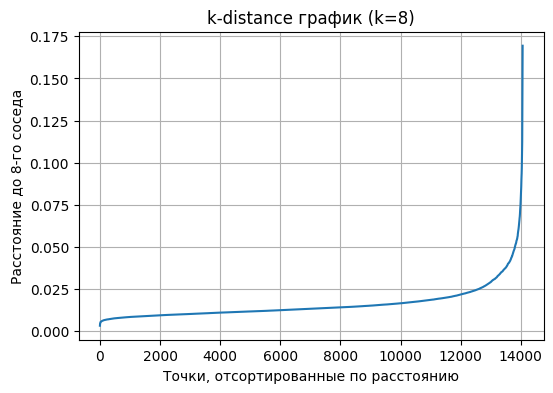

In [23]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

X_for_dbscan = doc_vectors_2d  # или другие признаки
k = 8  # это min_samples

# 1–2. считаем расстояния до k-го соседа
neigh = NearestNeighbors(n_neighbors=k)
neigh.fit(X_for_dbscan)
distances, indices = neigh.kneighbors(X_for_dbscan)

# расстояние до k-го соседа (столбец k-1)
k_distances = np.sort(distances[:, k-1])

# 3–4. строим график
plt.figure(figsize=(6, 4))
plt.plot(k_distances)
plt.title(f"k-distance график (k={k})")
plt.xlabel("Точки, отсортированные по расстоянию")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.grid(True)
plt.show()

In [60]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.0423674, min_samples=10)


cluster_labels = dbscan.fit_predict(doc_vectors_2d)

# -1 в DBSCAN означает "шум"
np.unique(cluster_labels, return_counts=True)

(array([-1,  0,  1,  2,  3,  4,  5]),
 array([  255, 13514,   251,    10,    15,     9,    10]))

In [61]:
df_subset["cluster"] = cluster_labels
df_subset[["title", "cluster"]].head(10)

,title,cluster
0,Подпорная стена обрушилась на припаркованные автомобили на улице Адмирала Кузнецова (ФОТО),0
1,Жители Владивостока обнаружили у Токаревского маяка мертвого китенка (ФОТО),0
2,На Адмирала Кузнецова упавшая подпорная стена повредила автомобиль (ФОТО),0
3,В Приморье фиксируются нарушения в ходе предвыборной кампании в Законодательное собрание,0
4,Следователи разыскивают очевидцев падения ворот на ребенка на острове Русском,0
5,На Станюковича часть дороги обрушилась при проведении строительных работ (ФОТО; ВИДЕО),0
6,Во Владивостоке водитель маршрутки побил несовершеннолетнего пассажира и забрал у него смартфон,0
7,Во Владивостоке школьник попал в больницу после избиения водителем маршрутки,0
8,Вертолет с Сергеем Дарькиным на борту совершил жесткую посадку в районе поселка Восток (ФОТО),0
9,"На Тигровой обрушилась подпорная стена, пострадали три автомобиля (ФОТО)",0


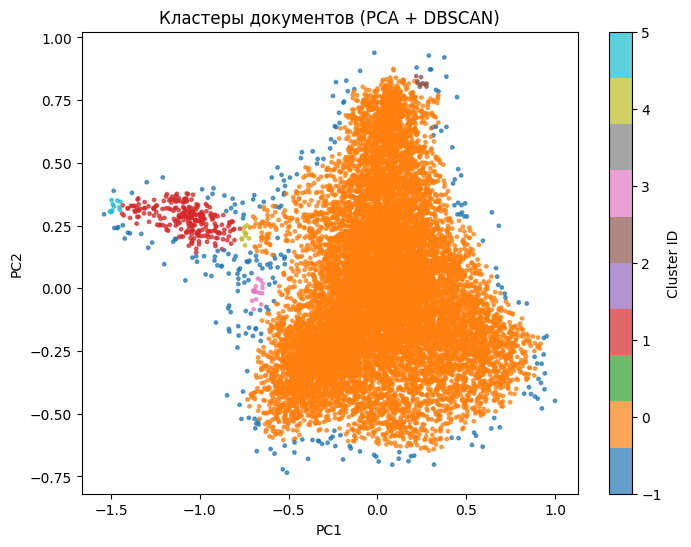

In [62]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_subset["pca_x"],
    df_subset["pca_y"],
    c=df_subset["cluster"],
    s=6,
    cmap="tab10",
    alpha=0.7,
)
plt.colorbar(scatter, label="Cluster ID")
plt.title("Кластеры документов (PCA + DBSCAN)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Предсказать кластеры методом DecisionTree

In [63]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

X = X_features
y = df_subset["cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"],
}

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
)

grid_dt.fit(X_train, y_train)

print("Лучшие параметры:", grid_dt.best_params_)
print("Лучший CV accuracy:", grid_dt.best_score_)

best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Лучшие параметры: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучший CV accuracy: 0.9905528373774165
Test accuracy: 0.9919431279620853
              precision    recall  f1-score   support

          -1       0.84      0.73      0.78        77
           0       1.00      1.00      1.00      4055
           1       0.99      1.00      0.99        75
           2       0.60      1.00      0.75         3
           3       0.75      0.75      0.75         4
           4       0.75      1.00      0.86         3
           5       1.00      1.00      1.00         3

    accuracy                           0.99      4220
   macro avg       0.85      0.92      0.87      4220
weighted avg       0.99      0.99      0.99      4220



## Предсказать кластеры методом KNN

In [65]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

X = X_features
y = df_subset["cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

knn = KNeighborsClassifier()

param_grid = {
    "n_neighbors": [3, 5, 10, 15, 25],
    "weights": ["uniform", "distance"],
    "metric": ["cosine", "euclidean"],
}

grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
)

grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучший CV accuracy:", grid.best_score_)

best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Лучшие параметры: {'metric': 'cosine', 'n_neighbors': 15, 'weights': 'uniform'}
Лучший CV accuracy: 0.9652578696999319
Test accuracy: 0.9672985781990522
              precision    recall  f1-score   support

          -1       0.67      0.05      0.10        77
           0       0.98      0.99      0.98      4055
           1       0.59      0.81      0.68        75
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         3

    accuracy                           0.97      4220
   macro avg       0.32      0.27      0.25      4220
weighted avg       0.96      0.97      0.96      4220



C:\Users\Qweeck\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Qweeck\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Qweeck\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(